# Machine Learning & Deep Learning — Prédiction de la Durée de Traitement

## Objectif

Prédire la **durée de traitement** (`duree_corrigee_totale`, en secondes) des dossiers d'assistance automobile à partir des caractéristiques du dossier, des intervenants et des garanties.

### Démarche

**Partie 1 — Machine Learning classique (scikit-learn)**
1. Régression Linéaire, Ridge, Lasso (baselines)
2. Random Forest
3. Gradient Boosting
4. XGBoost

**Partie 2 — Deep Learning (TensorFlow / Keras)**
5. MLP Simple (2 couches)
6. MLP Deep (4 couches + régularisation)
7. Wide & Deep (branche linéaire + branche profonde)
8. Residual MLP (connexions résiduelles)

**Partie 3 — Comparaison et sauvegarde**
9. Tableau comparatif ML vs DL (MAE, RMSE, MAPE)
10. Analyse du meilleur modèle
11. Sauvegarde des artefacts pour Streamlit

> **Transformation cible** : `log(1 + y)` pour stabiliser la variance (distribution à queue lourde).  
> Toutes les métriques sont reportées en **secondes** (échelle métier).

---

## 1. Imports et Configuration

In [1]:
# ============================================================
# IMPORTS
# ============================================================
import os
import time
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers, callbacks

# Configuration
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 13

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

PROC_DIR = '../data/processed'
MODEL_DIR = '../data/models'
os.makedirs(MODEL_DIR, exist_ok=True)

print(f"TensorFlow : {tf.__version__}")
print(f"NumPy      : {np.__version__}")

TensorFlow : 2.21.0
NumPy      : 2.3.0


## 2. Chargement des Données

In [2]:
# ============================================================
# CHARGEMENT DES DONNÉES
# ============================================================
# base_model.csv = dossiers avec durée > 0 (issus du traitement)
# On utilise uniquement cette base pour l'entraînement ET le test

base = pd.read_csv(f'{PROC_DIR}/base_model.csv')

print(f"Base : {base.shape[0]:,} dossiers x {base.shape[1]} colonnes")

# Variable cible
TARGET = 'duree_corrigee_totale'
print(f"\nVariable cible : {TARGET}")
print(f"  Min      = {base[TARGET].min():.0f}s")
print(f"  Médiane  = {base[TARGET].median():.0f}s")
print(f"  Max      = {base[TARGET].max():.0f}s")
print(f"  Skewness = {base[TARGET].skew():.2f} (asymétrie forte → log)")

Base : 86,950 dossiers x 34 colonnes

Variable cible : duree_corrigee_totale
  Min      = 5s
  Médiane  = 659s
  Max      = 58720s
  Skewness = 5.27 (asymétrie forte → log)


## 3. Sélection des Features

Mêmes variables que l'économétrie pour une comparaison équitable :
- **Numériques** : compteurs d'interventions, expérience, télétravail
- **Catégorielles** : cause, énergie, outil, type d'assistance, population, site, contrat
- **Binaires** : 6 variables TOP (garanties d'assistance)

In [3]:
# ============================================================
# DÉFINITION DES FEATURES
# ============================================================

FEAT_NUM = ['nb_interventions', 'nb_intervenants', 'prop_tele', 'exp_moy']

FEAT_CAT = ['Cause.intervention', 'Type.d.energie', 'Outil.d.assistance',
            'Assistance.ou.Administratif', 'pop_mode', 'site_mode', 'type_contrat_mode']

FEAT_BIN = ['TOP.D.R', 'TOP.VR', 'TOP.Rappat.valide',
            'TOP.Poursuite', 'TOP.Recup', 'TOP.Autres.Garanties']

ALL_FEATURES = FEAT_NUM + FEAT_CAT + FEAT_BIN

print(f"Features numériques   : {len(FEAT_NUM)}")
print(f"Features catégorielles : {len(FEAT_CAT)}")
print(f"Features binaires      : {len(FEAT_BIN)}")
print(f"Total                  : {len(ALL_FEATURES)}")

Features numériques   : 4
Features catégorielles : 7
Features binaires      : 6
Total                  : 17


## 4. Split Train / Test et Preprocessing

- **80% train** / **20% test** sur `base_model.csv`
- Transformation cible : `log(1 + y)` pour stabiliser la variance
- Preprocessing : StandardScaler (numériques + binaires), OneHotEncoder (catégorielles)

In [4]:
# ============================================================
# SPLIT TRAIN / TEST
# ============================================================

X = base[ALL_FEATURES].copy()
y = base[TARGET].values
y_log = np.log1p(y)  # log(1 + durée) : stabilise la distribution

X_train, X_test, y_train, y_test = train_test_split(
    X, y_log, test_size=0.2, random_state=SEED
)

print(f"Train : {X_train.shape[0]:,} dossiers ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Test  : {X_test.shape[0]:,} dossiers ({X_test.shape[0]/len(X)*100:.0f}%)")

# ============================================================
# PIPELINE DE PREPROCESSING
# ============================================================

preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), FEAT_NUM),
        ('bin', StandardScaler(with_mean=False), FEAT_BIN),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), FEAT_CAT),
    ]
)

# Application du preprocessing
X_train_p = preprocessor.fit_transform(X_train)
X_test_p  = preprocessor.transform(X_test)

print(f"\nDimension après preprocessing : {X_train_p.shape[1]} colonnes")

Train : 69,560 dossiers (80%)
Test  : 17,390 dossiers (20%)

Dimension après preprocessing : 36 colonnes


---
# PARTIE 1 : MACHINE LEARNING CLASSIQUE

## 5. Fonction d'évaluation

Métriques calculées en **secondes** (on inverse le log avec `expm1`) :
- **MAE** : erreur absolue moyenne
- **RMSE** : racine de l'erreur quadratique moyenne
- **MAPE** : erreur absolue moyenne en pourcentage

In [5]:
# ============================================================
# FONCTIONS D'ÉVALUATION
# ============================================================

def mape(y_true_sec, y_pred_sec):
    """Mean Absolute Percentage Error (en secondes)."""
    mask = y_true_sec > 0
    return np.mean(np.abs((y_true_sec[mask] - y_pred_sec[mask]) / y_true_sec[mask])) * 100

def evaluate_sklearn(model, X_tr, y_tr_log, X_te, y_te_log, name):
    """Entraîne un modèle sklearn, prédit et retourne les métriques en secondes."""
    t0 = time.time()
    model.fit(X_tr, y_tr_log)
    fit_time = time.time() - t0

    # Prédictions en log → inversion en secondes
    y_pred_tr_log = model.predict(X_tr)
    y_pred_te_log = model.predict(X_te)

    y_tr_sec  = np.expm1(y_tr_log)
    y_te_sec  = np.expm1(y_te_log)
    y_ptr_sec = np.clip(np.expm1(y_pred_tr_log), 0, None)
    y_pte_sec = np.clip(np.expm1(y_pred_te_log), 0, None)

    return {
        'Modèle': name,
        'MAE Train (s)': mean_absolute_error(y_tr_sec, y_ptr_sec),
        'MAE Test (s)': mean_absolute_error(y_te_sec, y_pte_sec),
        'RMSE Train (s)': np.sqrt(mean_squared_error(y_tr_sec, y_ptr_sec)),
        'RMSE Test (s)': np.sqrt(mean_squared_error(y_te_sec, y_pte_sec)),
        'MAPE Test (%)': mape(y_te_sec, y_pte_sec),
        'Temps (s)': fit_time,
    }

print("✓ Fonctions d'évaluation définies")

✓ Fonctions d'évaluation définies


## 6. Définition et Entraînement des Modèles ML

In [6]:
# ============================================================
# DÉFINITION DES MODÈLES ML
# ============================================================

models_ml = {
    'Régression Linéaire': Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', LinearRegression())
    ]),
    'Ridge (α=1.0)': Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', Ridge(alpha=1.0))
    ]),
    'Lasso (α=0.01)': Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', Lasso(alpha=0.01, max_iter=5000))
    ]),
    'Random Forest': Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', RandomForestRegressor(
            n_estimators=200, max_depth=15, min_samples_leaf=10,
            random_state=SEED, n_jobs=-1
        ))
    ]),
    'Gradient Boosting': Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', GradientBoostingRegressor(
            n_estimators=300, max_depth=5, learning_rate=0.1,
            subsample=0.8, random_state=SEED
        ))
    ]),
    'XGBoost': Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', XGBRegressor(
            n_estimators=300, max_depth=6, learning_rate=0.1,
            subsample=0.8, colsample_bytree=0.8,
            random_state=SEED, n_jobs=-1, verbosity=0
        ))
    ]),
}

print(f"✓ {len(models_ml)} modèles ML définis")

✓ 6 modèles ML définis


In [7]:
# ============================================================
# ENTRAÎNEMENT DES MODÈLES ML
# ============================================================

results_ml = []
trained_models = {}

for name, model in models_ml.items():
    print(f"► {name}...", end=" ")
    res = evaluate_sklearn(model, X_train, y_train, X_test, y_test, name)
    results_ml.append(res)
    trained_models[name] = model
    print(f"MAE={res['MAE Test (s)']:.0f}s | RMSE={res['RMSE Test (s)']:.0f}s | "
          f"MAPE={res['MAPE Test (%)']:.1f}% | t={res['Temps (s)']:.1f}s")

df_ml = pd.DataFrame(results_ml).set_index('Modèle')
print("\n✓ Entraînement ML terminé")

► Régression Linéaire... MAE=2653s | RMSE=119130s | MAPE=71.4% | t=0.2s
► Ridge (α=1.0)... MAE=2653s | RMSE=119175s | MAPE=71.4% | t=0.1s
► Lasso (α=0.01)... MAE=2778s | RMSE=124675s | MAPE=73.4% | t=0.1s
► Random Forest... MAE=453s | RMSE=909s | MAPE=44.3% | t=8.0s
► Gradient Boosting... MAE=444s | RMSE=892s | MAPE=43.9% | t=22.9s
► XGBoost... MAE=446s | RMSE=892s | MAPE=43.9% | t=0.7s

✓ Entraînement ML terminé


## 7. Résultats Machine Learning

=== COMPARAISON DES MODÈLES ML ===

                     MAE Train (s)  MAE Test (s)  RMSE Train (s)  RMSE Test (s)  MAPE Test (%)  Temps (s)
Modèle                                                                                                   
Gradient Boosting            411.3         444.4           787.9          891.5           43.9       22.9
XGBoost                      395.6         445.8           743.8          892.0           43.9        0.7
Random Forest                401.5         453.2           802.3          909.1           44.3        8.0
Régression Linéaire        73785.9        2652.7      11304840.2       119130.4           71.4        0.2
Ridge (α=1.0)              73793.8        2653.2      11306174.7       119174.9           71.4        0.1
Lasso (α=0.01)             98963.9        2777.9      15246774.1       124675.4           73.4        0.1

★ Meilleur modèle ML : Gradient Boosting


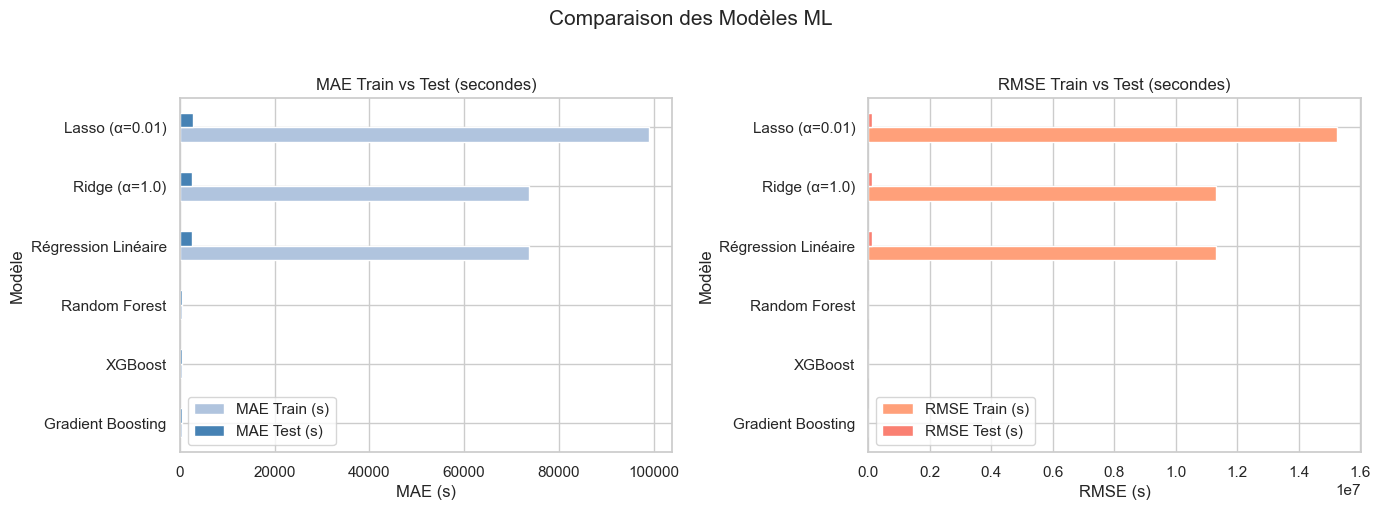

In [8]:
# ============================================================
# TABLEAU DE COMPARAISON ML
# ============================================================

display_cols_ml = ['MAE Train (s)', 'MAE Test (s)', 'RMSE Train (s)', 'RMSE Test (s)', 'MAPE Test (%)', 'Temps (s)']
df_ml_sorted = df_ml[display_cols_ml].sort_values('RMSE Test (s)')

print("=== COMPARAISON DES MODÈLES ML ===\n")
print(df_ml_sorted.round(1).to_string())

best_ml_name = df_ml_sorted.index[0]
print(f"\n★ Meilleur modèle ML : {best_ml_name}")

# --- Visualisation ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MAE Train vs Test
df_plot = df_ml_sorted[['MAE Train (s)', 'MAE Test (s)']].sort_values('MAE Test (s)')
df_plot.plot(kind='barh', ax=axes[0], color=['lightsteelblue', 'steelblue'], edgecolor='white')
axes[0].set_title('MAE Train vs Test (secondes)')
axes[0].set_xlabel('MAE (s)')

# RMSE Train vs Test
df_plot = df_ml_sorted[['RMSE Train (s)', 'RMSE Test (s)']].sort_values('RMSE Test (s)')
df_plot.plot(kind='barh', ax=axes[1], color=['lightsalmon', 'salmon'], edgecolor='white')
axes[1].set_title('RMSE Train vs Test (secondes)')
axes[1].set_xlabel('RMSE (s)')

plt.suptitle('Comparaison des Modèles ML', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

---
# PARTIE 2 : DEEP LEARNING (TensorFlow)

## 8. Architectures de Réseaux de Neurones

4 architectures de complexité croissante :

| Modèle | Description | Particularité |
|--------|------------|---------------|
| **MLP Simple** | 2 couches denses (64, 32) | Baseline DL |
| **MLP Deep** | 4 couches + Dropout + L2 | Régularisation contre l'overfitting |
| **Wide & Deep** | Branche linéaire + branche profonde | Capture effets linéaires et non-linéaires |
| **Residual MLP** | Connexions résiduelles (skip connections) | Apprentissage plus stable |

**Entraînement** : Adam (lr=1e-3), EarlyStopping (patience=10), ReduceLROnPlateau (patience=5)

In [9]:
# ============================================================
# ARCHITECTURES TENSORFLOW
# ============================================================

def _compile(model):
    """Compilation commune à tous les modèles DL."""
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='mse',
        metrics=['mae'],
    )
    return model

# --- 1. MLP Simple ---
def build_mlp_simple(n_in):
    m = keras.Sequential([
        keras.Input(shape=(n_in,)),
        layers.Dense(64, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(1),
    ], name='MLP_Simple')
    return _compile(m)

# --- 2. MLP Deep (régularisé) ---
def build_mlp_deep(n_in):
    m = keras.Sequential([
        keras.Input(shape=(n_in,)),
        layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(1e-5)),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(1e-5)),
        layers.Dropout(0.2),
        layers.Dense(32, activation='relu'),
        layers.Dense(16, activation='relu'),
        layers.Dense(1),
    ], name='MLP_Deep')
    return _compile(m)

# --- 3. Wide & Deep ---
def build_wide_deep(n_in):
    inp = keras.Input(shape=(n_in,))
    # Branche Wide (linéaire)
    wide = layers.Dense(1, name='wide')(inp)
    # Branche Deep (non-linéaire)
    deep = layers.Dense(64, activation='relu')(inp)
    deep = layers.Dense(32, activation='relu')(deep)
    deep = layers.Dense(16, activation='relu')(deep)
    # Fusion
    merged = layers.Concatenate()([wide, deep])
    out = layers.Dense(1)(merged)
    m = keras.Model(inputs=inp, outputs=out, name='Wide_and_Deep')
    return _compile(m)

# --- 4. Residual MLP ---
def build_residual(n_in):
    inp = keras.Input(shape=(n_in,))
    # Bloc 1
    x = layers.Dense(64, activation='relu')(inp)
    # Bloc 2 avec skip connection
    shortcut = x
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Add()([x, shortcut])  # Connexion résiduelle
    x = layers.Activation('relu')(x)
    # Sortie
    x = layers.Dense(32, activation='relu')(x)
    out = layers.Dense(1)(x)
    m = keras.Model(inputs=inp, outputs=out, name='Residual_MLP')
    return _compile(m)

print("✓ 4 architectures DL définies")

✓ 4 architectures DL définies


## 9. Entraînement et Évaluation des Modèles DL

In [10]:
# ============================================================
# BOUCLE D'ENTRAÎNEMENT DL
# ============================================================

def fit_eval_dl(name, build_fn, X_tr, y_tr, X_te, y_te, epochs=100, batch_size=512):
    """Entraîne un modèle Keras, évalue en secondes, retourne résultats + historique."""
    model = build_fn(X_tr.shape[1])

    cbs = [
        callbacks.EarlyStopping(
            patience=10, restore_best_weights=True, monitor='val_loss'),
        callbacks.ReduceLROnPlateau(
            patience=5, factor=0.5, min_lr=1e-5, monitor='val_loss'),
    ]

    t0 = time.time()
    hist = model.fit(
        X_tr, y_tr,
        validation_data=(X_te, y_te),
        epochs=epochs, batch_size=batch_size,
        callbacks=cbs, verbose=0,
    )
    fit_time = time.time() - t0

    # Prédictions en log → inversion en secondes
    y_pred_tr_log = model.predict(X_tr, verbose=0).ravel()
    y_pred_te_log = model.predict(X_te, verbose=0).ravel()

    y_tr_sec  = np.expm1(y_tr)
    y_te_sec  = np.expm1(y_te)
    y_ptr_sec = np.clip(np.expm1(y_pred_tr_log), 0, None)
    y_pte_sec = np.clip(np.expm1(y_pred_te_log), 0, None)

    return {
        'Modèle': name,
        'MAE Train (s)': mean_absolute_error(y_tr_sec, y_ptr_sec),
        'MAE Test (s)': mean_absolute_error(y_te_sec, y_pte_sec),
        'RMSE Train (s)': np.sqrt(mean_squared_error(y_tr_sec, y_ptr_sec)),
        'RMSE Test (s)': np.sqrt(mean_squared_error(y_te_sec, y_pte_sec)),
        'MAPE Test (%)': mape(y_te_sec, y_pte_sec),
        'Temps (s)': fit_time,
        'Epochs': len(hist.history['loss']),
        'model': model,
        'history': hist,
    }

# --- Entraînement ---
dl_architectures = {
    'MLP Simple': build_mlp_simple,
    'MLP Deep': build_mlp_deep,
    'Wide & Deep': build_wide_deep,
    'Residual MLP': build_residual,
}

results_dl = {}
for name, build_fn in dl_architectures.items():
    print(f"► {name}...", end=" ")
    res = fit_eval_dl(name, build_fn, X_train_p, y_train, X_test_p, y_test)
    results_dl[name] = res
    print(f"MAE={res['MAE Test (s)']:.0f}s | RMSE={res['RMSE Test (s)']:.0f}s | "
          f"MAPE={res['MAPE Test (%)']:.1f}% | epochs={res['Epochs']} | t={res['Temps (s)']:.1f}s")

print("\n✓ Entraînement DL terminé")

► MLP Simple... MAE=459s | RMSE=1061s | MAPE=45.0% | epochs=38 | t=5.6s
► MLP Deep... MAE=2260s | RMSE=146776s | MAPE=61.5% | epochs=11 | t=5.6s
► Wide & Deep... MAE=456s | RMSE=984s | MAPE=44.4% | epochs=100 | t=22.5s
► Residual MLP... MAE=452s | RMSE=926s | MAPE=44.6% | epochs=72 | t=14.4s

✓ Entraînement DL terminé


## 10. Courbes d'Apprentissage DL

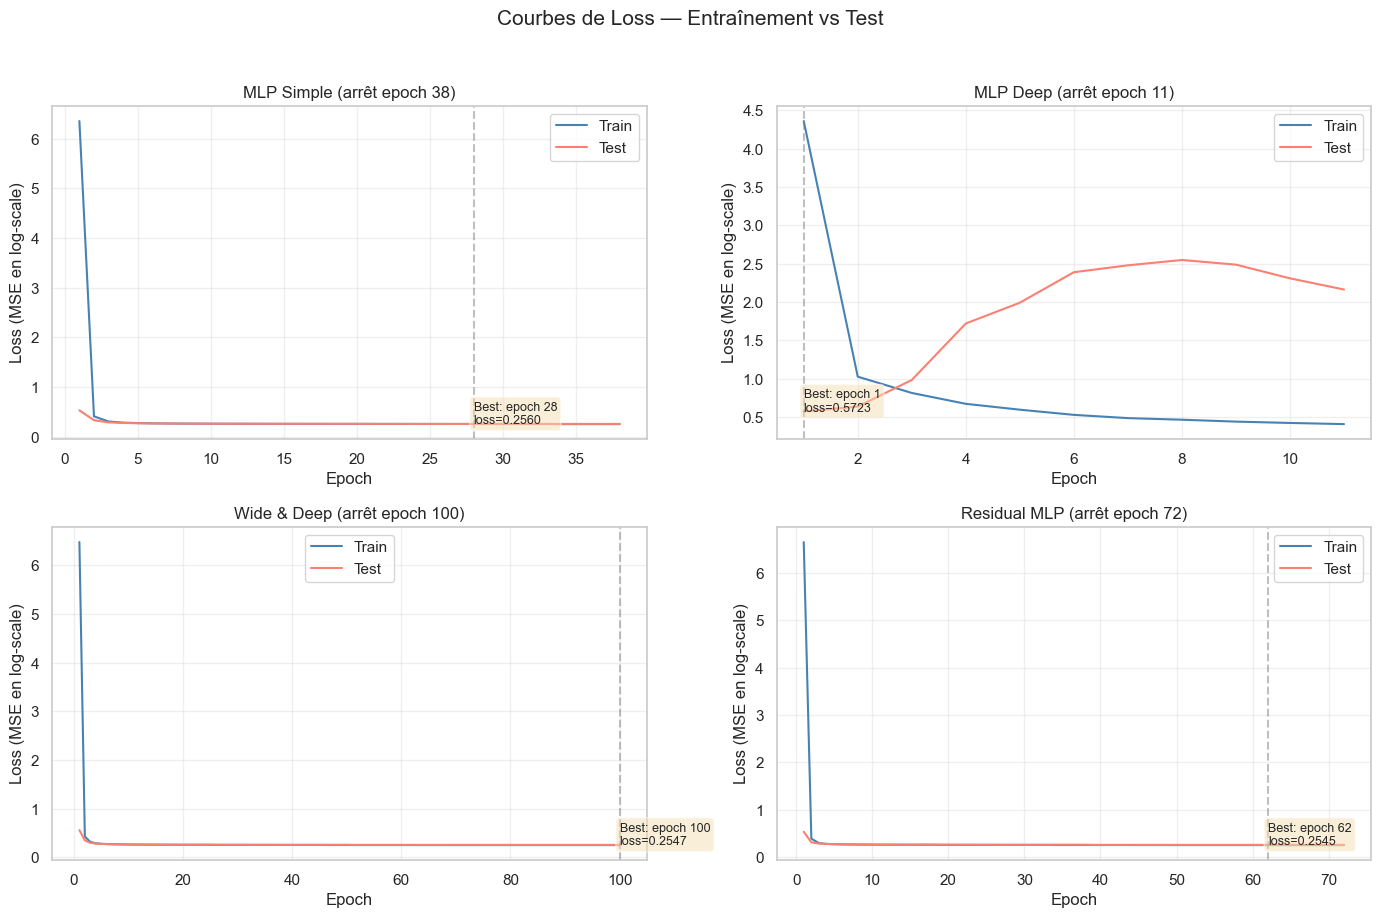

In [11]:
# ============================================================
# COURBES DE LOSS : ENTRAÎNEMENT vs TEST
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for ax, (name, res) in zip(axes.flat, results_dl.items()):
    h = res['history'].history
    epochs_range = range(1, len(h['loss']) + 1)

    ax.plot(epochs_range, h['loss'], label='Train', color='steelblue', linewidth=1.5)
    ax.plot(epochs_range, h['val_loss'], label='Test', color='salmon', linewidth=1.5)
    ax.set_title(f"{name} (arrêt epoch {res['Epochs']})")
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss (MSE en log-scale)')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Annoter la meilleure epoch
    best_epoch = np.argmin(h['val_loss']) + 1
    best_loss = min(h['val_loss'])
    ax.axvline(best_epoch, color='grey', linestyle='--', alpha=0.5)
    ax.annotate(f'Best: epoch {best_epoch}\nloss={best_loss:.4f}',
                xy=(best_epoch, best_loss), fontsize=9,
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Courbes de Loss — Entraînement vs Test', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

## 11. Résultats Deep Learning

In [12]:
# ============================================================
# TABLEAU DE COMPARAISON DL
# ============================================================

df_dl = pd.DataFrame([
    {k: v for k, v in res.items() if k not in ('model', 'history')}
    for res in results_dl.values()
]).set_index('Modèle')

display_cols_dl = ['MAE Train (s)', 'MAE Test (s)', 'RMSE Train (s)', 'RMSE Test (s)', 'MAPE Test (%)', 'Epochs', 'Temps (s)']
df_dl_sorted = df_dl[display_cols_dl].sort_values('RMSE Test (s)')

print("=== COMPARAISON DES MODÈLES DL ===\n")
print(df_dl_sorted.round(1).to_string())

best_dl_name = df_dl_sorted.index[0]
print(f"\n★ Meilleur modèle DL : {best_dl_name}")

=== COMPARAISON DES MODÈLES DL ===

              MAE Train (s)  MAE Test (s)  RMSE Train (s)  RMSE Test (s)  MAPE Test (%)  Epochs  Temps (s)
Modèle                                                                                                    
Residual MLP          429.7         452.1           836.4          926.0           44.6      72       14.4
Wide & Deep           428.9         456.2           844.9          983.7           44.4     100       22.5
MLP Simple            438.5         458.6           897.7         1061.0           45.0      38        5.6
MLP Deep            37418.1        2260.1       7674626.7       146775.9           61.5      11        5.6

★ Meilleur modèle DL : Residual MLP


---
# PARTIE 3 : COMPARAISON GLOBALE ET SAUVEGARDE

## 12. Comparaison ML vs DL

In [13]:
# ============================================================
# TABLEAU COMPARATIF GLOBAL : ML + DL
# ============================================================

# Combiner les résultats ML et DL
dl_rows = []
for name, res in results_dl.items():
    dl_rows.append({
        'Modèle': name,
        'MAE Train (s)': res['MAE Train (s)'],
        'MAE Test (s)': res['MAE Test (s)'],
        'RMSE Train (s)': res['RMSE Train (s)'],
        'RMSE Test (s)': res['RMSE Test (s)'],
        'MAPE Test (%)': res['MAPE Test (%)'],
        'Temps (s)': res['Temps (s)'],
    })

df_all = pd.concat([
    df_ml[['MAE Train (s)', 'MAE Test (s)', 'RMSE Train (s)', 'RMSE Test (s)', 'MAPE Test (%)', 'Temps (s)']],
    pd.DataFrame(dl_rows).set_index('Modèle')
]).sort_values('RMSE Test (s)')

# Colonne Type
df_all['Type'] = ['ML' if m in models_ml else 'DL' for m in df_all.index]

print("=" * 80)
print("COMPARAISON GLOBALE — ML vs DL")
print("=" * 80)
print(df_all.round(1).to_string())

best_name = df_all.index[0]
best_type = df_all.loc[best_name, 'Type']
print(f"\n★ MEILLEUR MODÈLE GLOBAL : {best_name} ({best_type})")
print(f"  MAE  = {df_all.loc[best_name, 'MAE Test (s)']:.0f}s")
print(f"  RMSE = {df_all.loc[best_name, 'RMSE Test (s)']:.0f}s")
print(f"  MAPE = {df_all.loc[best_name, 'MAPE Test (%)']:.1f}%")

COMPARAISON GLOBALE — ML vs DL
                     MAE Train (s)  MAE Test (s)  RMSE Train (s)  RMSE Test (s)  MAPE Test (%)  Temps (s) Type
Modèle                                                                                                        
Gradient Boosting            411.3         444.4           787.9          891.5           43.9       22.9   ML
XGBoost                      395.6         445.8           743.8          892.0           43.9        0.7   ML
Random Forest                401.5         453.2           802.3          909.1           44.3        8.0   ML
Residual MLP                 429.7         452.1           836.4          926.0           44.6       14.4   DL
Wide & Deep                  428.9         456.2           844.9          983.7           44.4       22.5   DL
MLP Simple                   438.5         458.6           897.7         1061.0           45.0        5.6   DL
Régression Linéaire        73785.9        2652.7      11304840.2       119130.4  

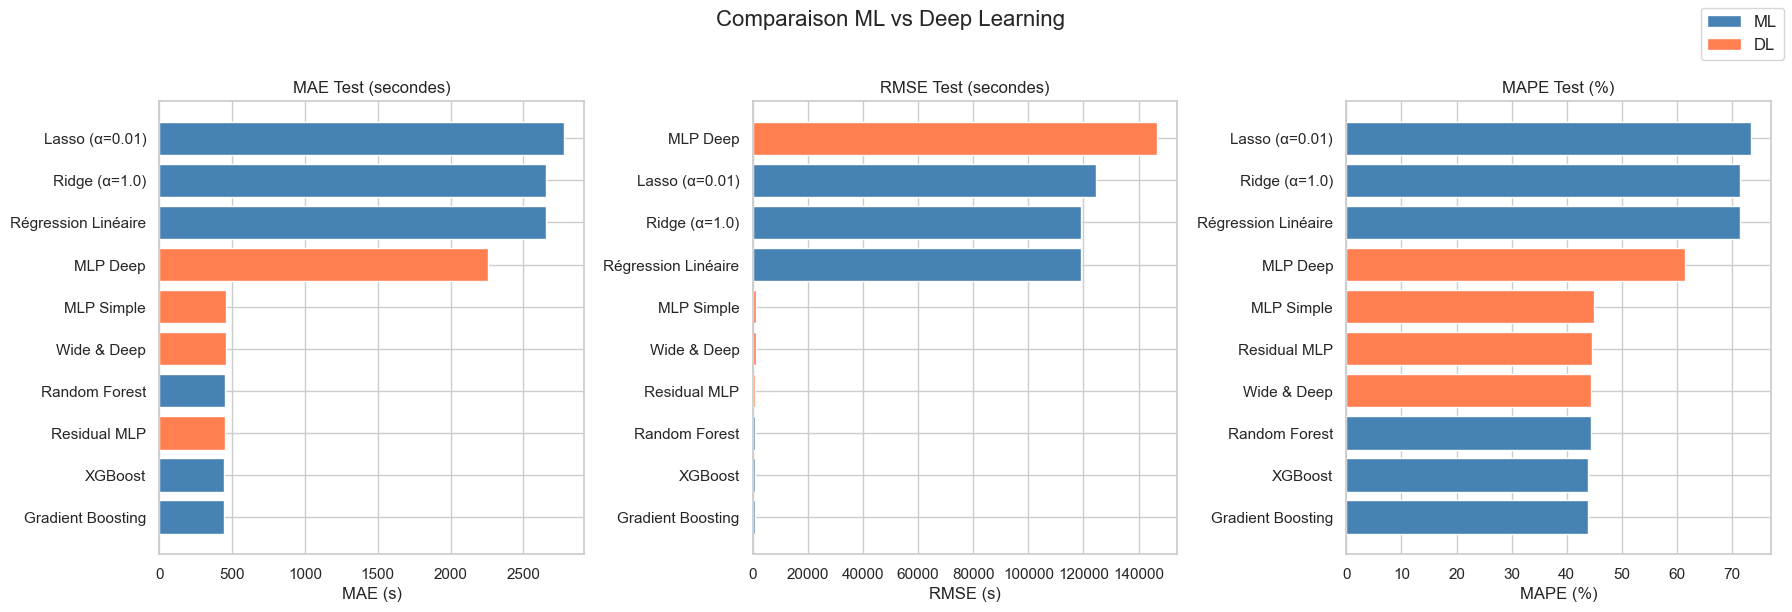

In [14]:
# ============================================================
# VISUALISATION COMPARATIVE ML vs DL
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# MAE
df_plot = df_all.sort_values('MAE Test (s)')
axes[0].barh(df_plot.index, df_plot['MAE Test (s)'],
             color=['steelblue' if t == 'ML' else 'coral' for t in df_plot['Type']],
             edgecolor='white')
axes[0].set_title('MAE Test (secondes)')
axes[0].set_xlabel('MAE (s)')

# RMSE
df_plot = df_all.sort_values('RMSE Test (s)')
axes[1].barh(df_plot.index, df_plot['RMSE Test (s)'],
             color=['steelblue' if t == 'ML' else 'coral' for t in df_plot['Type']],
             edgecolor='white')
axes[1].set_title('RMSE Test (secondes)')
axes[1].set_xlabel('RMSE (s)')

# MAPE
df_plot = df_all.sort_values('MAPE Test (%)')
axes[2].barh(df_plot.index, df_plot['MAPE Test (%)'],
             color=['steelblue' if t == 'ML' else 'coral' for t in df_plot['Type']],
             edgecolor='white')
axes[2].set_title('MAPE Test (%)')
axes[2].set_xlabel('MAPE (%)')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='steelblue', label='ML'),
                   Patch(facecolor='coral', label='DL')]
fig.legend(handles=legend_elements, loc='upper right', fontsize=12)

plt.suptitle('Comparaison ML vs Deep Learning', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## 13. Analyse du Meilleur Modèle

Meilleur modèle : Gradient Boosting (ML)


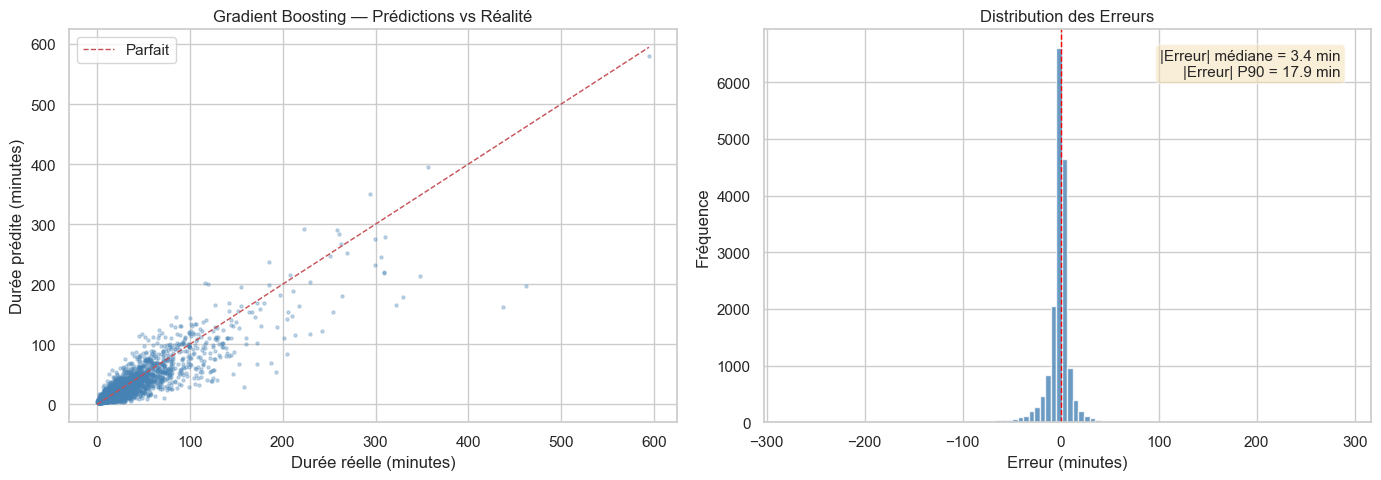

In [15]:
# ============================================================
# ANALYSE DU MEILLEUR MODÈLE
# ============================================================

best_global_name = df_all.index[0]
best_global_type = df_all.loc[best_global_name, 'Type']

print(f"Meilleur modèle : {best_global_name} ({best_global_type})")
print(f"{'=' * 50}")

# Prédictions sur test
if best_global_type == 'ML':
    best_pipeline = trained_models[best_global_name]
    y_pred_test_log = best_pipeline.predict(X_test)
else:
    best_dl_model = results_dl[best_global_name]['model']
    y_pred_test_log = best_dl_model.predict(X_test_p, verbose=0).ravel()

y_test_sec = np.expm1(y_test)
y_pred_test_sec = np.clip(np.expm1(y_pred_test_log), 0, None)

# --- Scatter : Prédictions vs Réalité ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

y_test_min = y_test_sec / 60
y_pred_min = y_pred_test_sec / 60

sample = np.random.choice(len(y_test_min), min(5000, len(y_test_min)), replace=False)
axes[0].scatter(y_test_min[sample], y_pred_min[sample], alpha=0.3, s=5, color='steelblue')
max_val = max(y_test_min.max(), y_pred_min.max())
axes[0].plot([0, max_val], [0, max_val], 'r--', linewidth=1, label='Parfait')
axes[0].set_xlabel('Durée réelle (minutes)')
axes[0].set_ylabel('Durée prédite (minutes)')
axes[0].set_title(f'{best_global_name} — Prédictions vs Réalité')
axes[0].legend()

# Distribution des erreurs
erreurs_min = (y_pred_test_sec - y_test_sec) / 60
axes[1].hist(erreurs_min, bins=100, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1)
axes[1].set_xlabel('Erreur (minutes)')
axes[1].set_ylabel('Fréquence')
axes[1].set_title('Distribution des Erreurs')
p50 = np.percentile(np.abs(erreurs_min), 50)
p90 = np.percentile(np.abs(erreurs_min), 90)
axes[1].annotate(f'|Erreur| médiane = {p50:.1f} min\n|Erreur| P90 = {p90:.1f} min',
                 xy=(0.95, 0.95), xycoords='axes fraction', ha='right', va='top',
                 fontsize=11, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

=== Erreur par quartile de durée ===

            MAE (min)  MAPE (%)
segment                        
Q1 (court)        2.2      74.2
Q2                2.8      33.9
Q3                5.8      35.4
Q4 (long)        18.8      32.1


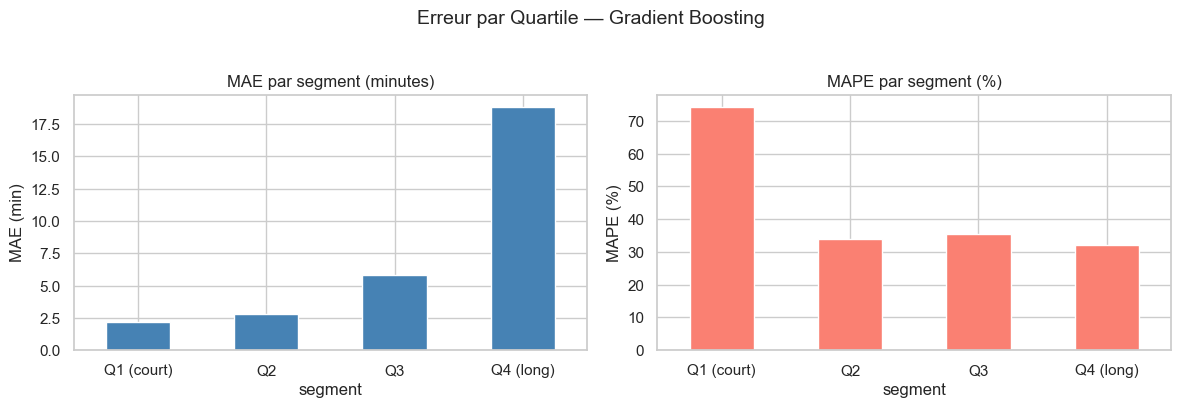

In [16]:
# ============================================================
# ERREUR PAR SEGMENT DE DURÉE
# ============================================================

quantiles_labels = ['Q1 (court)', 'Q2', 'Q3', 'Q4 (long)']
q_cuts = pd.qcut(y_test_sec, q=4, labels=quantiles_labels)

error_by_q = pd.DataFrame({
    'segment': q_cuts,
    'mae_min': np.abs(y_pred_test_sec - y_test_sec) / 60,
    'mape': np.abs((y_pred_test_sec - y_test_sec) / y_test_sec) * 100
}).groupby('segment').agg({'mae_min': 'mean', 'mape': 'mean'}).round(1)

error_by_q.columns = ['MAE (min)', 'MAPE (%)']
print("=== Erreur par quartile de durée ===\n")
print(error_by_q.to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
error_by_q['MAE (min)'].plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('MAE par segment (minutes)')
axes[0].set_ylabel('MAE (min)')
axes[0].tick_params(axis='x', rotation=0)

error_by_q['MAPE (%)'].plot(kind='bar', ax=axes[1], color='salmon', edgecolor='white')
axes[1].set_title('MAPE par segment (%)')
axes[1].set_ylabel('MAPE (%)')
axes[1].tick_params(axis='x', rotation=0)

plt.suptitle(f'Erreur par Quartile — {best_global_name}', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 14. Importance des Variables

Calcul de l'importance par permutation (Gradient Boosting)...


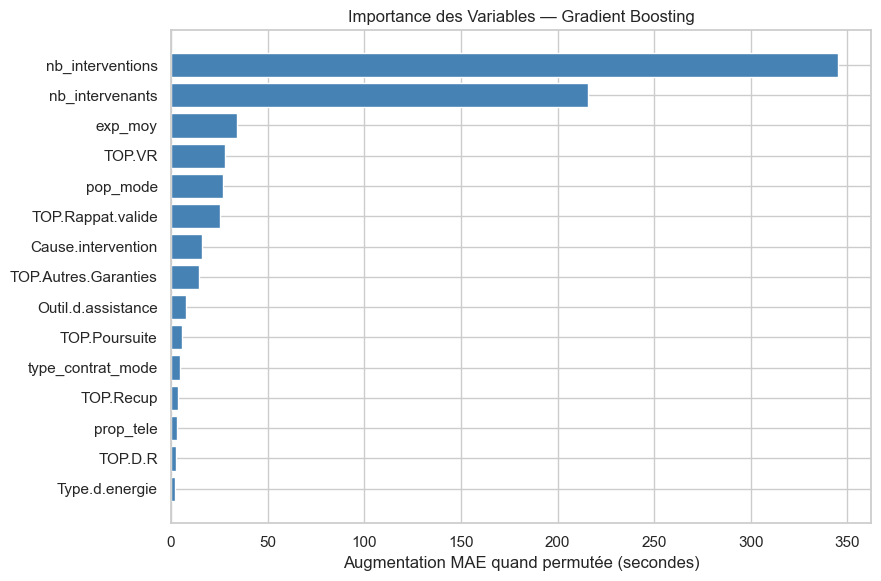


Top 10 features :
             Feature  Importance (s)
    nb_interventions      344.996576
     nb_intervenants      216.004160
             exp_moy       34.027877
              TOP.VR       27.697722
            pop_mode       26.923016
   TOP.Rappat.valide       25.521598
  Cause.intervention       16.016619
TOP.Autres.Garanties       14.257568
  Outil.d.assistance        7.611618
       TOP.Poursuite        5.673889


In [17]:
# ============================================================
# IMPORTANCE DES VARIABLES (PAR PERMUTATION)
# ============================================================

def permutation_importance_custom(predict_fn, X_raw, y_true_log, n_repeats=3):
    """Importance par permutation sur les colonnes d'origine."""
    rng = np.random.RandomState(SEED)
    y_true_sec = np.expm1(y_true_log)
    base_pred = np.clip(np.expm1(predict_fn(X_raw)), 0, None)
    base_mae = mean_absolute_error(y_true_sec, base_pred)

    importances = {}
    for col in X_raw.columns:
        drops = []
        for _ in range(n_repeats):
            X_shuf = X_raw.copy()
            X_shuf[col] = rng.permutation(X_shuf[col].values)
            pred_shuf = np.clip(np.expm1(predict_fn(X_shuf)), 0, None)
            mae_shuf = mean_absolute_error(y_true_sec, pred_shuf)
            drops.append(mae_shuf - base_mae)
        importances[col] = np.mean(drops)

    return pd.DataFrame({
        'Feature': list(importances.keys()),
        'Importance (s)': list(importances.values())
    }).sort_values('Importance (s)', ascending=False).reset_index(drop=True)

# Fonction de prédiction adaptée au type du meilleur modèle
if best_global_type == 'ML':
    predict_fn = lambda X: trained_models[best_global_name].predict(X)
else:
    predict_fn = lambda X: results_dl[best_global_name]['model'].predict(
        preprocessor.transform(X), verbose=0).ravel()

print(f"Calcul de l'importance par permutation ({best_global_name})...")
feat_imp = permutation_importance_custom(predict_fn, X_test, y_test, n_repeats=3)

# Affichage
fig, ax = plt.subplots(figsize=(9, 6))
top = feat_imp.head(15).iloc[::-1]
ax.barh(top['Feature'], top['Importance (s)'], color='steelblue', edgecolor='white')
ax.set_xlabel('Augmentation MAE quand permutée (secondes)')
ax.set_title(f'Importance des Variables — {best_global_name}')
plt.tight_layout()
plt.show()

print("\nTop 10 features :")
print(feat_imp.head(10).to_string(index=False))

## 15. Sauvegarde des Artefacts pour Streamlit

Fichiers sauvegardés dans `../data/models/` :
- **Tous les modèles ML** : `.pkl` (joblib)
- **Tous les modèles DL** : `.keras` (TensorFlow)
- **Preprocessor** : `.joblib`
- **Métadonnées** : features, noms des modèles
- **Tableau de comparaison** : `.csv`

In [18]:
# ============================================================
# SAUVEGARDE DE TOUS LES MODÈLES
# ============================================================

# --- 1. Modèles ML (joblib) ---
for name, model in trained_models.items():
    safe_name = name.replace(' ', '_').replace('(', '').replace(')', '').replace('α=', 'a')
    path = f'{MODEL_DIR}/ml_{safe_name}.pkl'
    joblib.dump(model, path)
    print(f"  ✓ {name} → {path}")

# --- 2. Modèles DL (keras) ---
for name, res in results_dl.items():
    safe_name = name.replace(' ', '_').replace('&', 'and')
    path = f'{MODEL_DIR}/dl_{safe_name}.keras'
    res['model'].save(path)
    print(f"  ✓ {name} → {path}")

# --- 3. Preprocessor ---
joblib.dump(preprocessor, f'{MODEL_DIR}/preprocessor.joblib')
print(f"  ✓ Preprocessor → {MODEL_DIR}/preprocessor.joblib")

# --- 4. Métadonnées ---
metadata = {
    'FEAT_NUM': FEAT_NUM,
    'FEAT_CAT': FEAT_CAT,
    'FEAT_BIN': FEAT_BIN,
    'ALL_FEATURES': ALL_FEATURES,
    'TARGET': TARGET,
    'best_model_name': best_global_name,
    'best_model_type': best_global_type,
    'models_ml': list(trained_models.keys()),
    'models_dl': list(results_dl.keys()),
}
joblib.dump(metadata, f'{MODEL_DIR}/ml_metadata.joblib')
print(f"  ✓ Métadonnées → {MODEL_DIR}/ml_metadata.joblib")

# --- 5. Tableau de comparaison ---
df_all.to_csv(f'{MODEL_DIR}/comparaison_modeles.csv')
print(f"  ✓ Comparaison → {MODEL_DIR}/comparaison_modeles.csv")

print(f"\n✓ {len(trained_models) + len(results_dl)} modèles sauvegardés dans {MODEL_DIR}/")

  ✓ Régression Linéaire → ../data/models/ml_Régression_Linéaire.pkl
  ✓ Ridge (α=1.0) → ../data/models/ml_Ridge_a1.0.pkl
  ✓ Lasso (α=0.01) → ../data/models/ml_Lasso_a0.01.pkl
  ✓ Random Forest → ../data/models/ml_Random_Forest.pkl
  ✓ Gradient Boosting → ../data/models/ml_Gradient_Boosting.pkl
  ✓ XGBoost → ../data/models/ml_XGBoost.pkl
  ✓ MLP Simple → ../data/models/dl_MLP_Simple.keras
  ✓ MLP Deep → ../data/models/dl_MLP_Deep.keras
  ✓ Wide & Deep → ../data/models/dl_Wide_and_Deep.keras
  ✓ Residual MLP → ../data/models/dl_Residual_MLP.keras
  ✓ Preprocessor → ../data/models/preprocessor.joblib
  ✓ Métadonnées → ../data/models/ml_metadata.joblib
  ✓ Comparaison → ../data/models/comparaison_modeles.csv

✓ 10 modèles sauvegardés dans ../data/models/


## 16. Synthèse

### Démarche

| Étape | Choix | Justification |
|-------|-------|---------------|
| Transformation cible | `log(1 + y)` | Distribution à queue lourde — stabilise l'entraînement |
| Split | 80% train / 20% test | Évaluation sur données non vues |
| Métriques | MAE, RMSE, MAPE en **secondes** | Échelle métier interprétable |
| ML classique | 6 modèles (linéaires + ensemblistes) | Du plus simple au plus complexe |
| Deep Learning | 4 architectures TensorFlow | MLP, Wide&Deep, Residual |
| Courbes de loss | Train vs Test par epoch | Détection d'overfitting |
| Sauvegarde | Tous les modèles + preprocessor | Réutilisation dans Streamlit |

### Artefacts pour Streamlit

| Fichier | Contenu |
|---------|---------|
| `ml_*.pkl` | Modèles ML (scikit-learn pipelines) |
| `dl_*.keras` | Modèles DL (TensorFlow) |
| `preprocessor.joblib` | Pipeline de preprocessing |
| `ml_metadata.joblib` | Features, noms des modèles, meilleur modèle |
| `comparaison_modeles.csv` | Tableau comparatif complet |

---